In [1]:
import os 
import numpy as np
import pandas as pd
from scipy.stats import zscore

import scanpy as sc 

import matplotlib.pyplot as plt
import seaborn as sns

from scroutines import powerplots

In [2]:
outfigdir = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/results_v1astro/260114"
!mkdir -p $outfigdir
fig_manager = powerplots.FigManager(outfigdir)

/u/home/f/f7xiesnm/project-zipursky/v1-bb/results_v1astro/260114


In [3]:
ddir = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized" 
!ls -alhtr $ddir/P28NRDR*

-rw-r--r--. 1 f7xiesnm zipursky 122M Apr 16  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240416.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 318M May  6  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240429.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 284M May  8  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240506.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 221M May  9  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1l23_merged_240508.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 664M Aug  1  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1_rna_merfish_240729.h5ad
-rw-r--r--. 1 f7xiesnm zipursky 371M Aug  8  2024 /u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/organized/P28NRDR_v1glut_rna_merfish_240729.h5ad
-rw-r--r--. 1 f7xiesnm zipursky  99M Aug  8  2024 /u/home/f/f7xiesnm/project-zipursky/

In [4]:
ddir2 = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/astro_john/cellchat_from_riki"
!ls $ddir2

28nr_vs_28dr_celladhesion.R	     ECM-Receptor_p28nr_vs_28dr.csv
Cell-Cell_Contact_p28nr_vs_28dr.csv  Secreted_Signaling_p28nr_vs_28dr.csv


In [5]:
f = "/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/merfish/merfish_genes.txt"
genes_mer = np.loadtxt(f, dtype=str)
genes_mer.shape

(500,)

# CellChat data
- forget about `.y` for now

In [6]:
f1_1 = os.path.join(ddir2, 'Cell-Cell_Contact_p28nr_vs_28dr.csv')
f1_2 = os.path.join(ddir2, 'ECM-Receptor_p28nr_vs_28dr.csv')
f1_3 = os.path.join(ddir2, 'Secreted_Signaling_p28nr_vs_28dr.csv')
df1_1 = pd.read_csv(f1_1, index_col=0)
df1_2 = pd.read_csv(f1_2, index_col=0)
df1_3 = pd.read_csv(f1_3, index_col=0)
df1 = pd.concat([df1_1, df1_2, df1_3], axis=0)
df1

,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT,ID (source_target_ligand_receptor)
1,AST_AST_CADM1_CADM1,AST,AST,Cadm1,Cadm1,0.442968,0.00,CADM1_CADM1,Cadm1 - Cadm1,CADM,...,CADM1_CADM1,Cadm1 - Cadm1,CADM,Cell-Cell Contact,PMID: 24503895,0.011429,AST_AST,AST_AST,AST_AST_AST_AST,NaN
2,AST_AST_CDH2_CDH2,AST,AST,Cdh2,Cdh2,0.277887,0.00,CDH2_CDH2,Cdh2 - Cdh2,CDH,...,NaN,NaN,NaN,NaN,NaN,0.556131,AST_AST,NA_NA,AST_AST_NA_NA,NaN
3,AST_AST_CDH4_CDH4,AST,AST,Cdh4,Cdh4,0.015306,0.00,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.056838,AST_AST,AST_AST,AST_AST_AST_AST,NaN
4,AST_AST_JAM2_JAM2,AST,AST,Jam2,Jam2,0.012186,0.00,JAM2_JAM2,Jam2 - Jam2,JAM,...,NaN,NaN,NaN,NaN,NaN,1.914150,AST_AST,NA_NA,AST_AST_NA_NA,NaN
5,AST_AST_LRRC4B_PTPRF,AST,AST,Lrrc4b,Ptprf,0.013946,0.00,LRRC4B_PTPRF,Lrrc4b - Ptprf,NGL,...,NaN,NaN,NaN,NaN,NaN,1.855541,AST_AST,NA_NA,AST_AST_NA_NA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1575,Vlp_Vlp_PTN_ALK,Vlp,Vlp,Ptn,Alk,0.028117,0.00,PTN_ALK,Ptn - Alk,PTN,...,NaN,NaN,NaN,NaN,NaN,1.551026,Vlp_Vlp,NA_NA,Vlp_Vlp_NA_NA,NaN
1576,Vlp_Vlp_PTN_PTPRZ1,Vlp,Vlp,Ptn,Ptprz1,0.026429,0.01,PTN_PTPRZ1,Ptn - Ptprz1,PTN,...,NaN,NaN,NaN,NaN,NaN,1.577916,Vlp_Vlp,NA_NA,Vlp_Vlp_NA_NA,NaN
1577,Vlp_Vlp_SEMA3C_NRP1_PLXNA2,Vlp,Vlp,Sema3c,NRP1_PLXNA2,0.056114,0.00,SEMA3C_NRP1_PLXNA2,Sema3c - (Nrp1+Plxna2),SEMA3,...,NaN,NaN,NaN,NaN,NaN,1.250932,Vlp_Vlp,NA_NA,Vlp_Vlp_NA_NA,NaN
1578,Vlp_Vlp_SEMA3C_NRP1_PLXNA4,Vlp,Vlp,Sema3c,NRP1_PLXNA4,0.069920,0.00,SEMA3C_NRP1_PLXNA4,Sema3c - (Nrp1+Plxna4),SEMA3,...,NaN,NaN,NaN,NaN,NaN,1.155398,Vlp_Vlp,NA_NA,Vlp_Vlp_NA_NA,NaN


In [7]:
cond_x = np.logical_xor(
    df1['source.x'] == 'AST', 
    df1['target.x'] == 'AST', 
)
cond_y = np.logical_xor(
    df1['source.y'] == 'AST', 
    df1['target.y'] == 'AST', 
)
cond = np.logical_or(cond_x, cond_y)

print(cond.sum())
df1sub = df1[cond]
df1sub = df1sub.fillna('NA')
df1sub

816


,ID,source.x,target.x,ligand.x,receptor.x,prob.x,pval.x,interaction_name.x,interaction_name_2.x,pathway_name.x,...,interaction_name.y,interaction_name_2.y,pathway_name.y,annotation.y,evidence.y,abslogPdif,INTastX,INTastY,INT,ID (source_target_ligand_receptor)
13,AST_INH_CDH4_CDH4,AST,INH,Cdh4,Cdh4,0.014647,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,NA,NA,NA,NA,NA,1.834258,AST_INH,NA_NA,AST_INH_NA_NA,NA
14,AST_INH_NCAM1_NCAM1,AST,INH,Ncam1,Ncam1,0.341554,0.0,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,...,NCAM1_NCAM1,Ncam1 - Ncam1,NCAM,Cell-Cell Contact,KEGG: mmu04514,0.002556,AST_INH,AST_INH,AST_INH_AST_INH,NA
15,AST_INH_PTPRM_PTPRM,NA,NA,NA,NA,1.000000,NA,NA,NA,NA,...,PTPRM_PTPRM,Ptprm - Ptprm,PTPRM,Cell-Cell Contact,KEGG: mmu04514,1.249561,NA_NA,AST_INH,NA_NA_AST_INH,NA
16,AST_L2/3_CADM1_CADM1,AST,L2/3,Cadm1,Cadm1,0.378108,0.0,CADM1_CADM1,Cadm1 - Cadm1,CADM,...,CADM1_CADM1,Cadm1 - Cadm1,CADM,Cell-Cell Contact,PMID: 24503895,0.002496,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3,NA
17,AST_L2/3_CDH4_CDH4,AST,L2/3,Cdh4,Cdh4,0.033974,0.0,CDH4_CDH4,Cdh4 - Cdh4,CDH,...,CDH4_CDH4,Cdh4 - Cdh4,CDH,Cell-Cell Contact,KEGG: mmu04514,0.415612,AST_L2/3,AST_L2/3,AST_L2/3_AST_L2/3,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1432,Vlp_AST_IGF1_IGF1R,Vlp,AST,Igf1,Igf1r,0.196906,0.0,IGF1_IGF1R,Igf1 - Igf1r,IGF,...,IGF1_IGF1R,Igf1 - Igf1r,IGF,Secreted Signaling,PMID: 14604834,0.061075,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST,NA
1433,Vlp_AST_PSAP_GPR37L1,Vlp,AST,Psap,Gpr37l1,0.046698,0.0,PSAP_GPR37L1,Psap - Gpr37l1,PSAP,...,PSAP_GPR37L1,Psap - Gpr37l1,PSAP,Secreted Signaling,PMID: 23690594,0.496421,Vlp_AST,Vlp_AST,Vlp_AST_Vlp_AST,NA
1434,Vlp_AST_PTN_PTPRZ1,Vlp,AST,Ptn,Ptprz1,0.055588,0.0,PTN_PTPRZ1,Ptn - Ptprz1,PTN,...,NA,NA,NA,NA,NA,1.255020,Vlp_AST,NA_NA,Vlp_AST_NA_NA,NA
1435,Vlp_AST_PTN_SDC4,Vlp,AST,Ptn,Sdc4,0.008844,0.0,PTN_SDC4,Ptn - Sdc4,PTN,...,NA,NA,NA,NA,NA,2.053335,Vlp_AST,NA_NA,Vlp_AST_NA_NA,NA


In [8]:
df1sub['receptor.x'].unique()

array(['Cdh4', 'Ncam1', 'NA', 'Cadm1', 'ITGAV_ITGB1', 'Jam3', 'Ptprf',
       'L1cam', 'Nlgn1', 'Nlgn2', 'NRP1_PLXNA2', 'NRP1_PLXNA4', 'Ntng1',
       'Ncam2', 'Nlgn3', 'Ptprm', 'Cdh2', 'Negr1', 'Nectin1', 'Fgfr1',
       'NRP1_PLXNA1', 'Plxna1', 'Jam2', 'Nrcam', 'Ephb1', 'Notch1',
       'Notch2', 'Plxnb1', 'Nectin3', 'Sdc4', 'Cd47', 'ITGAV_ITGB8',
       'Dag1', 'Sv2b', 'Sv2a', 'Sv2c', 'ITGA9_ITGB1', 'Fgfr2', 'Ncl',
       'Ptprz1', 'Sdc2', 'Sdc3', 'Alk', 'Erbb4', 'Gpr37l1', 'Ntrk2',
       'Mertk', 'Pdgfrb', 'Fgfr3', 'Insr', 'Igf1r'], dtype=object)

In [9]:
mols_x = np.union1d(df1sub['ligand.x'].unique(), 
                    df1sub['receptor.x'].unique())

mols_y = np.union1d(df1sub['ligand.y'].unique(), 
                    df1sub['receptor.y'].unique())

mols = np.union1d(mols_x, mols_y)

mols_mer = np.intersect1d(mols, genes_mer)
len(mols), len(mols_mer), mols, mols_mer

(100,
 21,
 array(['Agrn', 'Alk', 'Bdnf', 'CNTN1_CNTNAP1', 'Cadm1', 'Cd47', 'Cdh2',
        'Cdh4', 'Cntn1', 'Col4a1', 'Col4a2', 'Col6a1', 'Col9a3', 'Dag1',
        'Efnb2', 'Epha4', 'Ephb1', 'Erbb4', 'FZD3_LRP6', 'Fgf1', 'Fgf10',
        'Fgf5', 'Fgf9', 'Fgfr1', 'Fgfr2', 'Fgfr3', 'Fzd3', 'Gas6',
        'Gpr37l1', 'ITGA9_ITGB1', 'ITGAV_ITGB1', 'ITGAV_ITGB3',
        'ITGAV_ITGB8', 'Igf1', 'Igf1r', 'Insr', 'Jag2', 'Jam2', 'Jam3',
        'L1cam', 'Lama2', 'Lama3', 'Lama4', 'Lamc1', 'Lamc2', 'Lrrc4b',
        'Lrrc4c', 'Mertk', 'NA', 'NRP1_PLXNA1', 'NRP1_PLXNA2',
        'NRP1_PLXNA4', 'Nampt', 'Ncam1', 'Ncam2', 'Ncl', 'Nectin1',
        'Nectin3', 'Negr1', 'Nfasc', 'Nlgn1', 'Nlgn2', 'Nlgn3', 'Notch1',
        'Notch2', 'Nrcam', 'Nrg1', 'Nrg3', 'Nrxn1', 'Nrxn2', 'Nrxn3',
        'Ntng1', 'Ntrk2', 'Pdgfa', 'Pdgfb', 'Pdgfrb', 'Plxna1', 'Plxna2',
        'Plxna4', 'Plxnb1', 'Psap', 'Ptn', 'Ptprf', 'Ptprm', 'Ptprz1',
        'Pvr', 'Sdc2', 'Sdc3', 'Sdc4', 'Sema4a', 'Sema4d', 'Sema6a',
     

In [10]:
cond2_x = np.logical_and(
    df1sub['ligand.x'].isin(mols_mer),
    df1sub['receptor.x'].isin(mols_mer),
)
cond2_y = np.logical_and(
    df1sub['ligand.y'].isin(mols_mer),
    df1sub['receptor.y'].isin(mols_mer),
)
cond2 = np.logical_or(cond2_x, cond2_y)
df1sub2 = df1sub[cond2]
len(df1sub2)

78

In [11]:
df1sub2.sort_values('abslogPdif', ascending=False).to_csv('check_nrdr.csv')

In [12]:
print(df1sub2['ligand.x'].unique())
print(df1sub2['receptor.x'].unique())
print(df1sub2['ligand.y'].unique())
print(df1sub2['receptor.y'].unique())

genes_cellchat = np.unique(np.hstack([df1sub2['ligand.x'], 
                                      df1sub2['receptor.x'],
                                      df1sub2['ligand.y'], 
                                      df1sub2['receptor.y'],
                                     ]))

genes_cellchat = genes_cellchat[genes_cellchat!="NA"]
genes_cellchat

['Cdh4' 'NA' 'Ptprm' 'Negr1' 'Sema6d' 'Col6a1' 'Gas6']
['Cdh4' 'NA' 'Ptprm' 'Negr1' 'Plxna1' 'Sdc4' 'Mertk']
['NA' 'Ptprm' 'Cdh4' 'Sema6a' 'Negr1' 'Gas6']
['NA' 'Ptprm' 'Cdh4' 'Plxna4' 'Negr1' 'Mertk']


array(['Cdh4', 'Col6a1', 'Gas6', 'Mertk', 'Negr1', 'Plxna1', 'Plxna4',
       'Ptprm', 'Sdc4', 'Sema6a', 'Sema6d'], dtype=object)

In [13]:
df1sub2s_x = df1sub2[df1sub2['source.x']=='AST']
df1sub2t_x = df1sub2[df1sub2['target.x']=='AST']

df1sub2s_y = df1sub2[df1sub2['source.y']=='AST']
df1sub2t_y = df1sub2[df1sub2['target.y']=='AST']

In [14]:
summary_s_x = df1sub2s_x.groupby(['target.x', 'interaction_name.x']).first()['prob.x'].unstack().fillna(0).sort_index().sort_index(axis=1)
summary_t_x = df1sub2t_x.groupby(['source.x', 'interaction_name.x']).first()['prob.x'].unstack().fillna(0).sort_index().sort_index(axis=1)
summary_s_x = summary_s_x.loc[['L2/3', 'L4', 'L5IT', 'L5PT', 'L6CTb', 'Pvalb', 'Sst', 'Vlp']]
summary_t_x = summary_t_x.loc[['L2/3', 'L4', 'L5IT', 'L5PT', 'L6CTb', 'Pvalb', 'Sst', 'Vlp']]
summary_s_x.shape, summary_t_x.shape

((8, 4), (8, 5))

In [15]:
summary_s_y = df1sub2s_y.groupby(['target.y', 'interaction_name.y']).first()['prob.y'].unstack().fillna(0).sort_index().sort_index(axis=1)
summary_t_y = df1sub2t_y.groupby(['source.y', 'interaction_name.y']).first()['prob.y'].unstack().fillna(0).sort_index().sort_index(axis=1)
summary_s_y = summary_s_y.loc[['L2/3', 'L4', 'L5IT', 'L5PT', 'L6CTb', 'Pvalb', 'Sst', 'Vlp']]
summary_t_y = summary_t_y.loc[['L2/3', 'L4', 'L5IT', 'L5PT', 'L6CTb', 'Pvalb', 'Sst', 'Vlp']]
summary_s_y.shape, summary_t_y.shape

((8, 4), (8, 4))

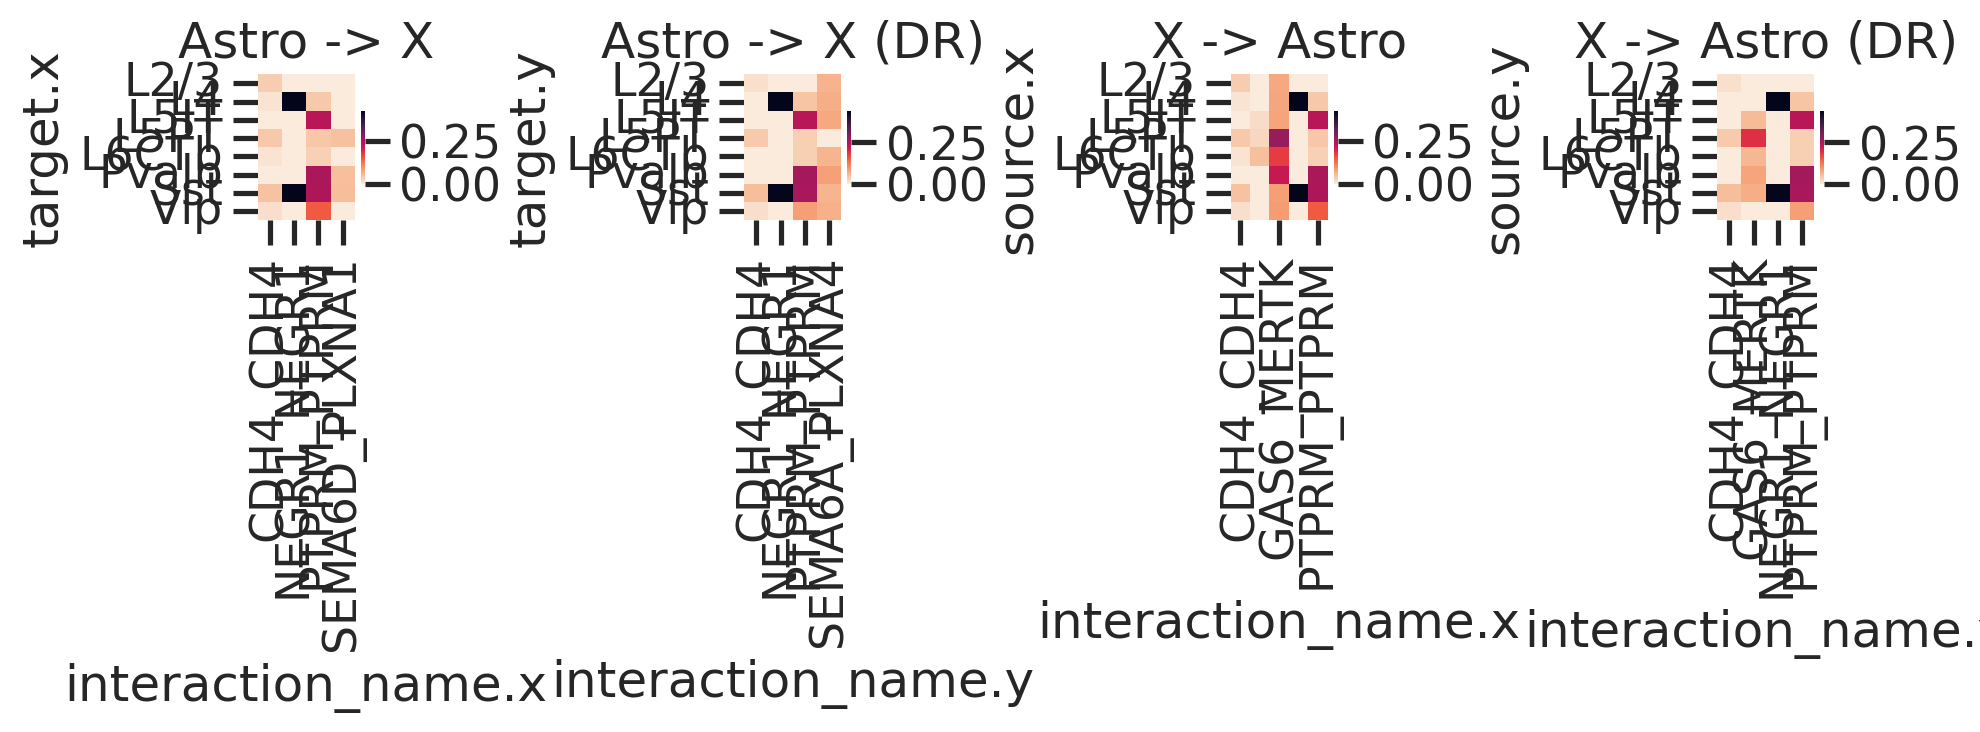

In [16]:
fig, axs = plt.subplots(1,4,figsize=(2.5*4,4))
ax = axs[0]
sns.heatmap(summary_s_x, 
            cbar_kws={'shrink':0.5, }, cmap='rocket_r', ax=ax)
ax.set_title('Astro -> X')

ax = axs[1]
sns.heatmap(summary_s_y, 
            cbar_kws={'shrink':0.5, }, cmap='rocket_r', ax=ax)
ax.set_title('Astro -> X (DR)')

ax = axs[2]
sns.heatmap(summary_t_x, 
            cbar_kws={'shrink':0.5, }, cmap='rocket_r', ax=ax)
ax.set_title('X -> Astro')

ax = axs[3]
sns.heatmap(summary_t_y, 
            cbar_kws={'shrink':0.5, }, cmap='rocket_r', ax=ax)
ax.set_title('X -> Astro (DR)')

fig.tight_layout()
plt.show()

# RNA data

In [17]:
from scipy import sparse

In [18]:
def preprocessing(adata):
    # filter genes
    cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
    adata_sub = adata[:,cond]

    # counts
    x = adata_sub.X
    cov = adata_sub.obs['n_counts'].values

    # CP10k
    xn = (sparse.diags(1/cov).dot(x))*1e4

    # log10(CP10k+1)
    xln = xn.copy()
    xln.data = np.log10(xln.data+1)

    adata_sub.layers['norm'] = xn
    adata_sub.layers['lognorm'] = xln
    
    return adata_sub

In [19]:
def get_hvgs(adata, layer, nbin=20, qth=0.3):
    """
    """
    xn = adata.layers[layer]
    
    # min
    gm = np.ravel(xn.mean(axis=0))

    # var
    tmp = xn.copy()
    tmp.data = np.power(tmp.data, 2)
    gv = np.ravel(tmp.mean(axis=0))-gm**2

    # cut 
    lbl = pd.qcut(gm, nbin, labels=np.arange(nbin))
    gres = pd.DataFrame()
    gres['lbl'] = lbl
    gres['mean'] = gm
    gres['var'] = gv
    gres['ratio']= gv/gm

    # select
    gres_sel = gres.groupby('lbl')['ratio'].nlargest(int(qth*(len(gm)/nbin))) #.reset_index()
    gsel_idx = np.sort(gres_sel.index.get_level_values(1).values)

    assert np.all(gsel_idx != -1)
    
    return adata.var.index.values[gsel_idx]

In [20]:
#
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/cheng21_cell_scrna/organized/P28NR.h5ad'
adata_rna_raw = sc.read(f)
adata_rna_raw

AnnData object with n_obs × n_vars = 23930 × 53801
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass'

In [21]:
adata_rna_raw = preprocessing(adata_rna_raw)
adata_rna_raw

AnnData object with n_obs × n_vars = 23930 × 24498
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass'
    layers: 'norm', 'lognorm'

In [22]:
genes_cellchat_rna = np.intersect1d(adata_rna_raw.var.index.values, genes_cellchat)
genes_cellchat_rna

array(['Cdh4', 'Col6a1', 'Gas6', 'Mertk', 'Negr1', 'Plxna1', 'Plxna4',
       'Ptprm', 'Sdc4', 'Sema6a', 'Sema6d'], dtype=object)

# MERFISH data - check these 5 genes

In [23]:
import sys
sys.path.insert(0, '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/myvisctx/analysis_merfish')
import merfish_genesets
import merfish_datasets
import utils_merfish

from scroutines import basicu

In [24]:
def unify_labels(a, b):
    """
    """
    b = b.replace('NA', np.nan)
    
    cat_a = a.cat.categories
    cat_b = b.cat.categories
    
    if len(cat_a)==len(cat_b) and np.all(cat_a==cat_b):
        u = a.fillna(b)
    else:
        cats = np.union1d(cat_a, cat_b)
        a = a.cat.set_categories(cats).copy()
        b = b.cat.set_categories(cats).copy()
        u = a.fillna(b)
        
    return u

In [25]:
%%time
names = [
    'P28NRa_ant', 
    'P28NRa_pos',
    
    'P28NRb_ant', 
    'P28NRb_pos',
    
    'P28DRa_ant', 
    'P28DRa_pos',
    
    'P28DRb_ant', 
    'P28DRb_pos',
]

alldata = {}
for name in names:
    adatasub = sc.read(os.path.join(ddir, f'{name}_l2_v1_240723.h5ad')) 
    adatasub.obs.index = np.char.add(f'{name}', adatasub.obs.index.values)
    alldata[name] = adatasub 
    print(name, len(alldata[name]))
    
genes = adatasub.var.index.values
genes.shape

P28NRa_ant 4875
P28NRa_pos 9816
P28NRb_ant 2984
P28NRb_pos 12329
P28DRa_ant 5986
P28DRa_pos 7733
P28DRb_ant 10244
P28DRb_pos 8207
CPU times: user 770 ms, sys: 1.2 s, total: 1.97 s
Wall time: 8.25 s


(500,)

In [26]:
genesets, df = merfish_genesets.get_all_genesets()
iegs   = genesets['i']
genes_noniegs = np.array([g for g in genes if g not in iegs])
igenes_idx = basicu.get_index_from_array(adatasub.var.index.values, iegs)

In [27]:
mean_total_rna_target = 250
adata_merged = []
for i, name in enumerate(names):
    j = i // 4
    i = i % 4
    
    adatasub = alldata[name].copy()
    adatasub.obs['sample'] = name
    
    norm_cnts = adatasub.layers['norm']
    # mean_per_batch = np.mean(norm_cnts.sum(axis=1))
    mean_per_batch_noniegs = np.mean(adatasub[:,genes_noniegs].layers['norm'].sum(axis=1))
    
    adatasub.layers['jnorm']  = norm_cnts*(mean_total_rna_target/mean_per_batch_noniegs)
    adatasub.layers['ljnorm'] = np.log2(1+adatasub.layers['jnorm'])
    
    adatasub.obs['norm_transcript_count']  = adatasub.layers['norm'].sum(axis=1)
    adatasub.obs['jnorm_transcript_count'] = adatasub.layers['jnorm'].sum(axis=1)
    
    adatasub.obs['depth_show'] = -adatasub.obs['depth'].values - i*1300 # name
    adatasub.obs['width_show'] =  adatasub.obs['width'].values - np.min(adatasub.obs['width'].values) + j*2500   # name
    
    adata_merged.append(adatasub)
    
adata_merged = sc.concat(adata_merged)
adata_merged

AnnData object with n_obs × n_vars = 62174 × 500
    obs: 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'sample', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show'
    obsm: 'X_pca', 'X_xy', 'blanks'
    layers: 'jnorm', 'norm', 'ljnorm'

# Metadata

In [28]:
f = os.path.join(ddir, "P28NRDR_v1_rna_merfish_240729.h5ad")
adata = sc.read(f)

f = os.path.join(ddir, "P28NRDR_v1glut_rna_merfish_240729.h5ad")
adata_exc = sc.read(f, backed='r')
f = os.path.join(ddir, "P28NRDR_v1gaba_rna_merfish_240729.h5ad")
adata_inh = sc.read(f, backed='r')

# organize uClass and uSubclass
a = adata.obs['Class_broad']
b = adata.obs['gated_pred']
adata.obs['uClass'] = unify_labels(a, b)

a = adata_exc.obs['Subclass']
b = adata_exc.obs['gated_pred_subclass']
adata_exc.obs['uSubclass'] = unify_labels(a, b)

a = adata_inh.obs['Subclass']
b = adata_inh.obs['gated_pred_subclass']
adata_inh.obs['uSubclass'] = unify_labels(a, b)

uSubclass = pd.concat([adata_exc.obs['uSubclass'], adata_inh.obs['uSubclass']])
adata.obs = adata.obs.join(uSubclass)
adata.obs['uSubclass'] = adata.obs['uSubclass'].fillna(adata.obs['uClass'])
adata.obs

,batch,n_genes,percent_mito,n_counts,leiden,Doublet Score,cluster,Class_broad,sample,Age,...,leiden_r0.3,umap1,umap2,umap1_self,umap2_self,max_pred,frac_self_neighbors,gated_pred,uClass,uSubclass
AAACCCACAAATGATG-1-P28_1a-P28,P28,3450.0,0.000951,10513.0,3,0.023377,L6CT_B,Excitatory,P28_1a,P28,...,NaN,8.267126,17.154900,NaN,NaN,NA,NaN,NA,Excitatory,L6CT
AAACCCACACCCTAGG-1-P28_1a-P28,P28,4622.0,0.002900,15174.0,2,0.055276,L4_C,Excitatory,P28_1a,P28,...,NaN,11.621952,4.318666,NaN,NaN,NA,NaN,NA,Excitatory,L4
AAACCCAGTTCTCTCG-1-P28_1a-P28,P28,4895.0,0.002141,16814.0,6,0.040816,L2/3_B,Excitatory,P28_1a,P28,...,NaN,12.320524,-0.034990,NaN,NaN,NA,NaN,NA,Excitatory,L2/3
AAACCCATCACTTGTT-1-P28_1a-P28,P28,3751.0,0.000471,12745.0,3,0.012605,L6CT_B,Excitatory,P28_1a,P28,...,NaN,7.646397,16.957756,NaN,NaN,NA,NaN,NA,Excitatory,L6CT
AAACCCATCCTAGCTC-1-P28_1a-P28,P28,4327.0,0.001903,13661.0,1,0.028505,L4_C,Excitatory,P28_1a,P28,...,NaN,15.032149,6.807268,NaN,NaN,NA,NaN,NA,Excitatory,L4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P28DRb_pos49001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,4.143420,5.953799,7.271769,5.800007,Oligodendrocytes,0.90,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes
P28DRb_pos49020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,3.795387,11.158264,4.908178,4.226176,OPCs,0.54,OPCs,OPCs,OPCs
P28DRb_pos49040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,2.996678,10.856749,4.674964,4.261509,OPCs,0.71,OPCs,OPCs,OPCs
P28DRb_pos49073,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P28DRb_pos,NaN,...,3,5.964211,4.365138,7.940835,5.199085,Oligodendrocytes,0.56,Oligodendrocytes,Oligodendrocytes,Oligodendrocytes


In [29]:
adata_merged.obs

,EntityID,fov,volume,center_x,center_y,min_x,min_y,max_x,max_y,anisotropy,...,blended_domains,x2,y2,depth,width,sample,norm_transcript_count,jnorm_transcript_count,depth_show,width_show
P28NRa_ant214236,2595481502624100078,2269,69.309363,12094.184978,6147.414453,12085.551440,6142.846693,12101.562420,6152.728010,1.719774,...,7,1954.735378,1069.544143,1091.081863,7090.367674,P28NRa_ant,627.620831,662.184596,-1091.081863,1090.346632
P28NRa_ant219236,2595481502678100047,2248,111.117518,12048.608568,6237.787188,12044.391522,6233.308738,12051.563595,6241.611470,1.631610,...,7,1858.604816,1101.219928,1076.375370,6992.847297,P28NRa_ant,692.960042,731.122109,-1076.375370,992.826254
P28NRa_ant219246,2595481502678100059,2248,100.689861,12027.438036,6259.726479,12023.429063,6253.828613,12030.937756,6266.051136,1.760410,...,7,1828.121567,1101.763523,1081.084014,6962.725003,P28NRa_ant,218.492703,230.525335,-1081.084014,962.703960
P28NRa_ant219247,2595481502678100060,2248,59.089495,12050.041692,6259.456534,12046.597595,6254.578000,12052.943771,6263.207243,1.468012,...,7,1844.295646,1117.555842,1062.744660,6975.941139,P28NRa_ant,220.005263,232.121194,-1062.744660,975.920096
P28NRa_ant219281,2595481502678100119,2248,380.133967,12026.613099,6259.015436,12019.273876,6252.891351,12031.579141,6266.838696,1.185538,...,7,1828.041033,1100.677421,1082.167779,6962.832515,P28NRa_ant,416.958267,439.920614,-1082.167779,962.811472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P28DRb_pos49020,2027846600588100079,905,432.537334,4908.459448,1264.769815,4903.774890,1260.646940,4913.055581,1268.891176,1.383461,...,5,-2036.610743,373.450997,1049.199752,1020.868049,P28DRb_pos,167.615589,163.697174,-4949.199752,2520.511250
P28DRb_pos49025,2027846600588100088,905,162.775695,4909.892717,1258.938500,4904.879308,1255.350400,4914.077210,1263.662314,1.628380,...,5,-2041.456988,376.996755,1043.199728,1021.109310,P28DRb_pos,104.438196,101.996704,-4943.199728,2520.752511
P28DRb_pos49040,2027846600588100126,905,258.331509,4915.854359,1266.010441,4912.092150,1262.397482,4919.635790,1269.471107,1.655364,...,5,-2041.478115,367.747265,1048.339504,1013.419301,P28DRb_pos,141.291320,137.988298,-4948.339504,2513.062502
P28DRb_pos49073,2027846600588100186,905,199.815348,4900.551323,1272.853467,4895.566390,1266.046817,4905.201039,1279.539903,1.616163,...,5,-2025.356696,372.341805,1059.160472,1026.222292,P28DRb_pos,320.295717,312.808039,-4959.160472,2525.865493


In [30]:
adata_merged = adata_merged[adata[adata.obs['modality']=='merfish'].obs.index]
adata_merged_nr = adata_merged[adata_merged.obs['sample'].str.contains(r'^P28NR')]
adata_merged_dr = adata_merged[adata_merged.obs['sample'].str.contains(r'^P28DR')]
adata_merged

View of AnnData object with n_obs × n_vars = 43961 × 500
    obs: 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'sample', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show'
    obsm: 'X_pca', 'X_xy', 'blanks'
    layers: 'jnorm', 'norm', 'ljnorm'

In [31]:
adata_merged_nr

View of AnnData object with n_obs × n_vars = 21172 × 500
    obs: 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'sample', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show'
    obsm: 'X_pca', 'X_xy', 'blanks'
    layers: 'jnorm', 'norm', 'ljnorm'

In [32]:
adata_merged_dr

View of AnnData object with n_obs × n_vars = 22789 × 500
    obs: 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'sample', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show'
    obsm: 'X_pca', 'X_xy', 'blanks'
    layers: 'jnorm', 'norm', 'ljnorm'

In [33]:
genes_cellchat_mer = np.intersect1d(genes, genes_cellchat)
genes_cellchat_mer

array(['Cdh4', 'Col6a1', 'Gas6', 'Mertk', 'Negr1', 'Plxna1', 'Plxna4',
       'Ptprm', 'Sdc4', 'Sema6a', 'Sema6d'], dtype=object)

In [34]:
genes_show = genes_cellchat_mer #['Cdh4', 'Negr1', 'Ptprm', 'Plxna1', 'Sema6d']

In [35]:
adata_rna = adata[adata.obs['modality']=='rna']

adata_mer = adata[adata.obs['modality']=='merfish']
adata_mer_nr = adata_mer[adata_mer.obs['sample'].str.contains(r'^P28NR')]
adata_mer_dr = adata_mer[adata_mer.obs['sample'].str.contains(r'^P28DR')]

print(adata_rna.shape)
print(adata_mer.shape)
print(adata_mer_nr.shape)
print(adata_mer_dr.shape)

(23930, 361)
(43961, 361)
(21172, 361)
(22789, 361)


In [36]:
adata_rna

View of AnnData object with n_obs × n_vars = 23930 × 361
    obs: 'batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden', 'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass', 'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID', 'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x', 'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio', 'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw', 'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y', 'blended_domains', 'x2', 'y2', 'depth', 'width', 'norm_transcript_count', 'jnorm_transcript_count', 'depth_show', 'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self', 'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'uClass', 'uSubclass'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_pca2', 'X_pca_harmony', 'X_umap', 'X_xy', 'blanks', 'pca', 'umap'
    layers: 'jnorm', 'ljnorm', 'lognorm', 'norm'
    obsp: 'connectivities', 'distances'

In [37]:
adata_rna.obs['sample'].unique()

['P28_1a', 'P28_1b', 'P28_2a', 'P28_2b']
Categories (4, object): ['P28_1a', 'P28_1b', 'P28_2a', 'P28_2b']

In [38]:
adata_mer.obs['sample'].unique()


['P28NRa_ant', 'P28NRa_pos', 'P28NRb_ant', 'P28NRb_pos', 'P28DRa_ant', 'P28DRa_pos', 'P28DRb_ant', 'P28DRb_pos']
Categories (8, object): ['P28DRa_ant', 'P28DRa_pos', 'P28DRb_ant', 'P28DRb_pos', 'P28NRa_ant', 'P28NRa_pos', 'P28NRb_ant', 'P28NRb_pos']

In [39]:
sel_adata_raw = adata_rna_raw
sel_adata = adata_rna
sel_col = 'uSubclass'
sel_layer = 'lognorm'
sel_genes = genes_show
sel_data = np.array(sel_adata_raw[:,sel_genes].layers[sel_layer].todense())

dfval = sel_adata.obs[[sel_col]].copy()
dfval[sel_genes] = sel_data
dfval_mean = dfval.groupby(sel_col).mean()
dfval_mean_zscore = zscore(dfval_mean, axis=0)
print(dfval_mean.mean())

Cdh4      0.147746
Col6a1    0.074665
Gas6      0.128737
Mertk     0.180596
Negr1     1.031003
Plxna1    0.052232
Plxna4    0.448452
Ptprm     0.481507
Sdc4      0.018526
Sema6a    0.220727
Sema6d    0.516741
dtype: float32


In [40]:
sel_adata_raw = adata_merged_nr
sel_adata = adata_mer_nr 
sel_col = 'uSubclass'
sel_layer = 'ljnorm'
sel_genes = genes_show
sel_data = np.array(sel_adata_raw[:,sel_genes].layers[sel_layer])

dfval2 = sel_adata.obs[[sel_col]].copy()
dfval2[sel_genes] = sel_data
dfval2_mean = dfval2.groupby(sel_col).mean()
dfval2_mean_zscore = zscore(dfval2_mean, axis=0)
print(dfval2_mean.mean())

Cdh4      0.313370
Col6a1    0.545119
Gas6      1.002758
Mertk     0.298976
Negr1     0.290379
Plxna1    0.855071
Plxna4    0.970024
Ptprm     0.879181
Sdc4      0.184349
Sema6a    0.164057
Sema6d    0.272572
dtype: float64


In [41]:
sel_adata_raw = adata_merged_dr
sel_adata = adata_mer_dr 
sel_col = 'uSubclass'
sel_layer = 'ljnorm'
sel_genes = genes_show
sel_data = np.array(sel_adata_raw[:,sel_genes].layers[sel_layer])

dfval3 = sel_adata.obs[[sel_col]].copy()
dfval3[sel_genes] = sel_data
dfval3_mean = dfval3.groupby(sel_col).mean()
dfval3_mean_zscore = zscore(dfval3_mean, axis=0)
print(dfval3_mean.mean())

Cdh4      0.248677
Col6a1    0.586128
Gas6      0.964886
Mertk     0.263173
Negr1     0.286772
Plxna1    0.766920
Plxna4    0.830487
Ptprm     0.909764
Sdc4      0.197711
Sema6a    0.186813
Sema6d    0.276544
dtype: float64


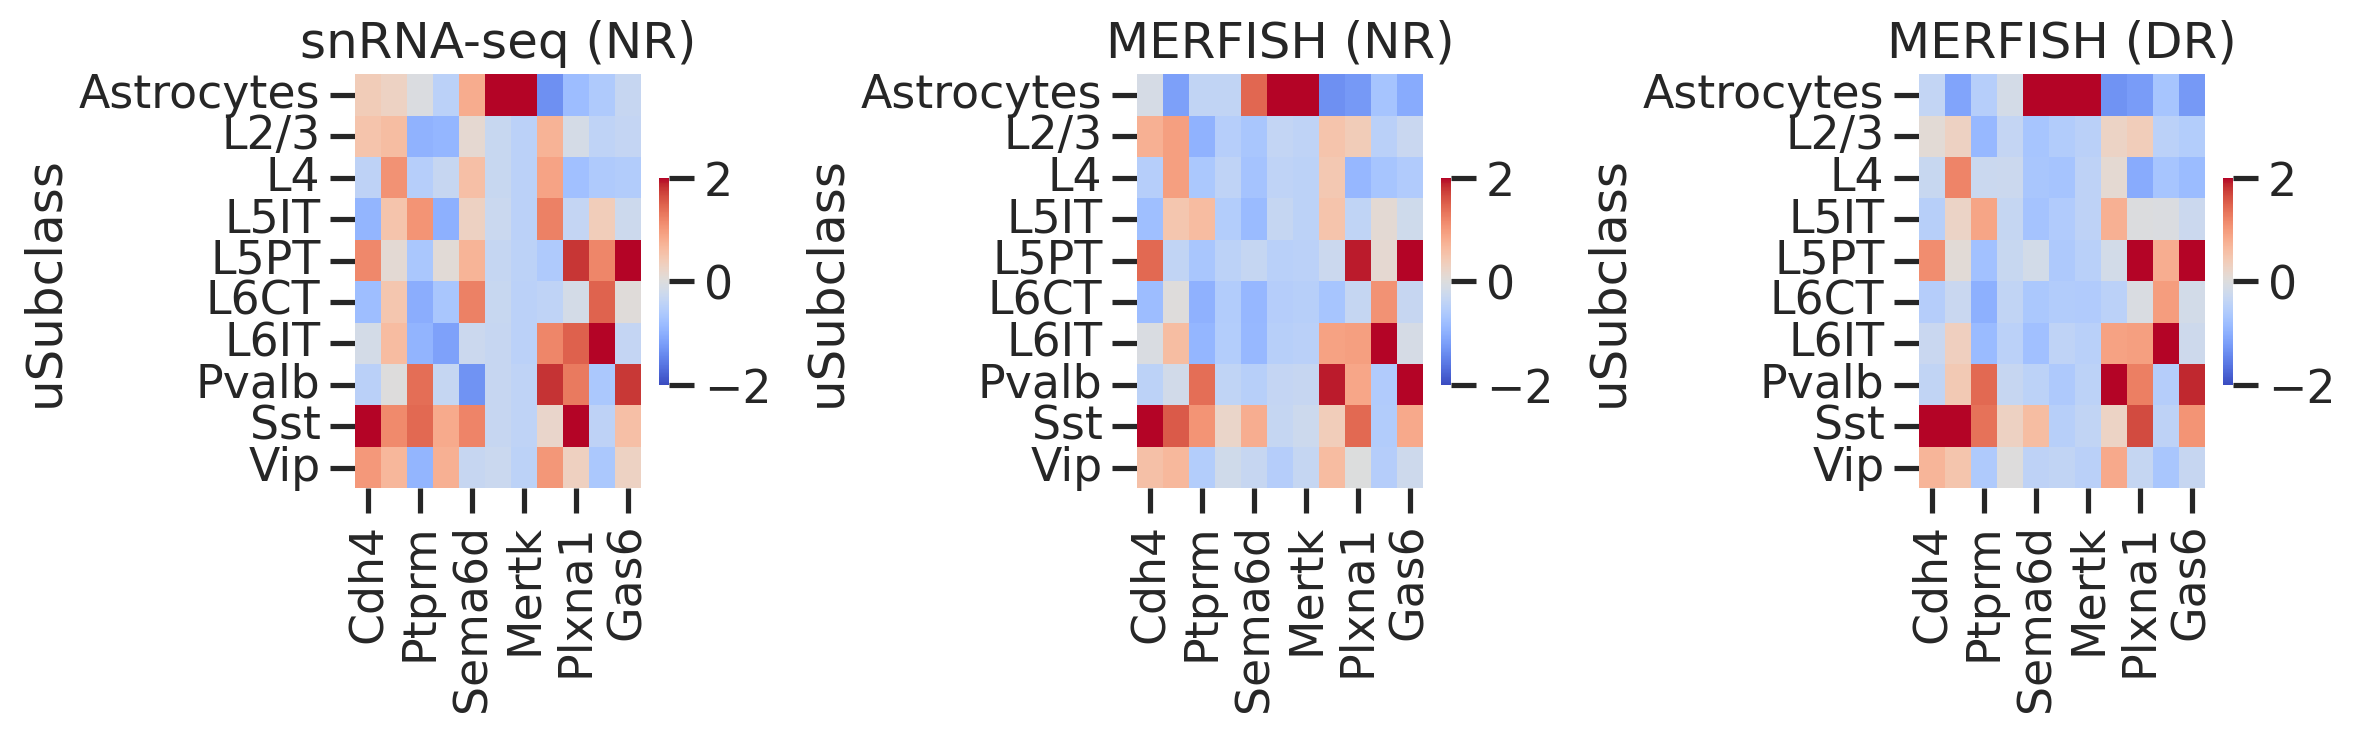

In [42]:
selrows = [
    "Astrocytes", 
    
    "L2/3", "L4", 
    "L5IT", "L5PT", 
    "L6CT", "L6IT",
    "Pvalb", "Sst", "Vip",
    
    # "Endothelial",
    # "OPCs",
    # "Oligodendrocytes",
    # "Microglia",
    # "VLMCs",
]

selcols = [
    'Cdh4', 'Negr1', 'Ptprm',
    'Sema6a', 'Sema6d', 'Sdc4', 'Mertk', 
    'Plxna4', 'Plxna1', 'Col6a1', 'Gas6',
]

fig, axs = plt.subplots(1,3,figsize=(4*3,1*4))
ax = axs[0]
ax.set_title('snRNA-seq (NR)')
sns.heatmap( dfval_mean_zscore.loc[selrows][selcols],
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

ax = axs[1]
ax.set_title('MERFISH (NR)')
sns.heatmap(dfval2_mean_zscore.loc[selrows][selcols], 
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)

ax = axs[2]
ax.set_title('MERFISH (DR)')
sns.heatmap(dfval3_mean_zscore.loc[selrows][selcols], 
            vmax=2, vmin=-2, cmap='coolwarm', 
            cbar_kws=dict(shrink=0.5),
            ax=ax)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()

# visualize 1 gene
- Col6a1

In [43]:
adata_mer.obs.columns

Index(['batch', 'n_genes', 'percent_mito', 'n_counts', 'leiden',
       'Doublet Score', 'cluster', 'Class_broad', 'sample', 'Age', 'subclass',
       'sample_new', 'layer', 'Type', 'Subclass', 'modality', 'EntityID',
       'fov', 'volume', 'center_x', 'center_y', 'min_x', 'min_y', 'max_x',
       'max_y', 'anisotropy', 'transcript_count', 'perimeter_area_ratio',
       'solidity', 'PolyT_raw', 'PolyT_high_pass', 'DAPI_raw',
       'DAPI_high_pass', 'gncov', 'gnnum', 'fpcov', 'x', 'y',
       'blended_domains', 'x2', 'y2', 'depth', 'width',
       'norm_transcript_count', 'jnorm_transcript_count', 'depth_show',
       'width_show', 'leiden_r0.3', 'umap1', 'umap2', 'umap1_self',
       'umap2_self', 'max_pred', 'frac_self_neighbors', 'gated_pred', 'uClass',
       'uSubclass'],
      dtype='object')

In [44]:
width_min = adata_mer_nr.obs.groupby('sample')['width'].min().reindex(names)
width_max = adata_mer_nr.obs.groupby('sample')['width'].max().reindex(names)
width_rng = width_max - width_min 
width_cum = pd.Series(np.cumsum(np.hstack([0, width_rng[:-1]+100])), index=names)

adata_mer_nr.obs['width_n0']    =  adata_mer_nr.obs['width']    - width_min.reindex(adata_mer_nr.obs['sample']).values
adata_mer_nr.obs['width_show2'] =  adata_mer_nr.obs['width_n0'] + width_cum.reindex(adata_mer_nr.obs['sample']).values
adata_mer_nr.obs['depth_show2'] = -adata_mer_nr.obs['depth']

/tmp/ipykernel_254003/4142495873.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_mer_nr.obs['width_n0']    =  adata_mer_nr.obs['width']    - width_min.reindex(adata_mer_nr.obs['sample']).values


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


saved the figure to: /u/home/f/f7xiesnm/project-zipursky/v1-bb/results_v1astro/260114/24_2026-01-14.pdf
/u/home/f/f7xiesnm/project-zipursky/v1-bb/results_v1astro/260114/24.pdf


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


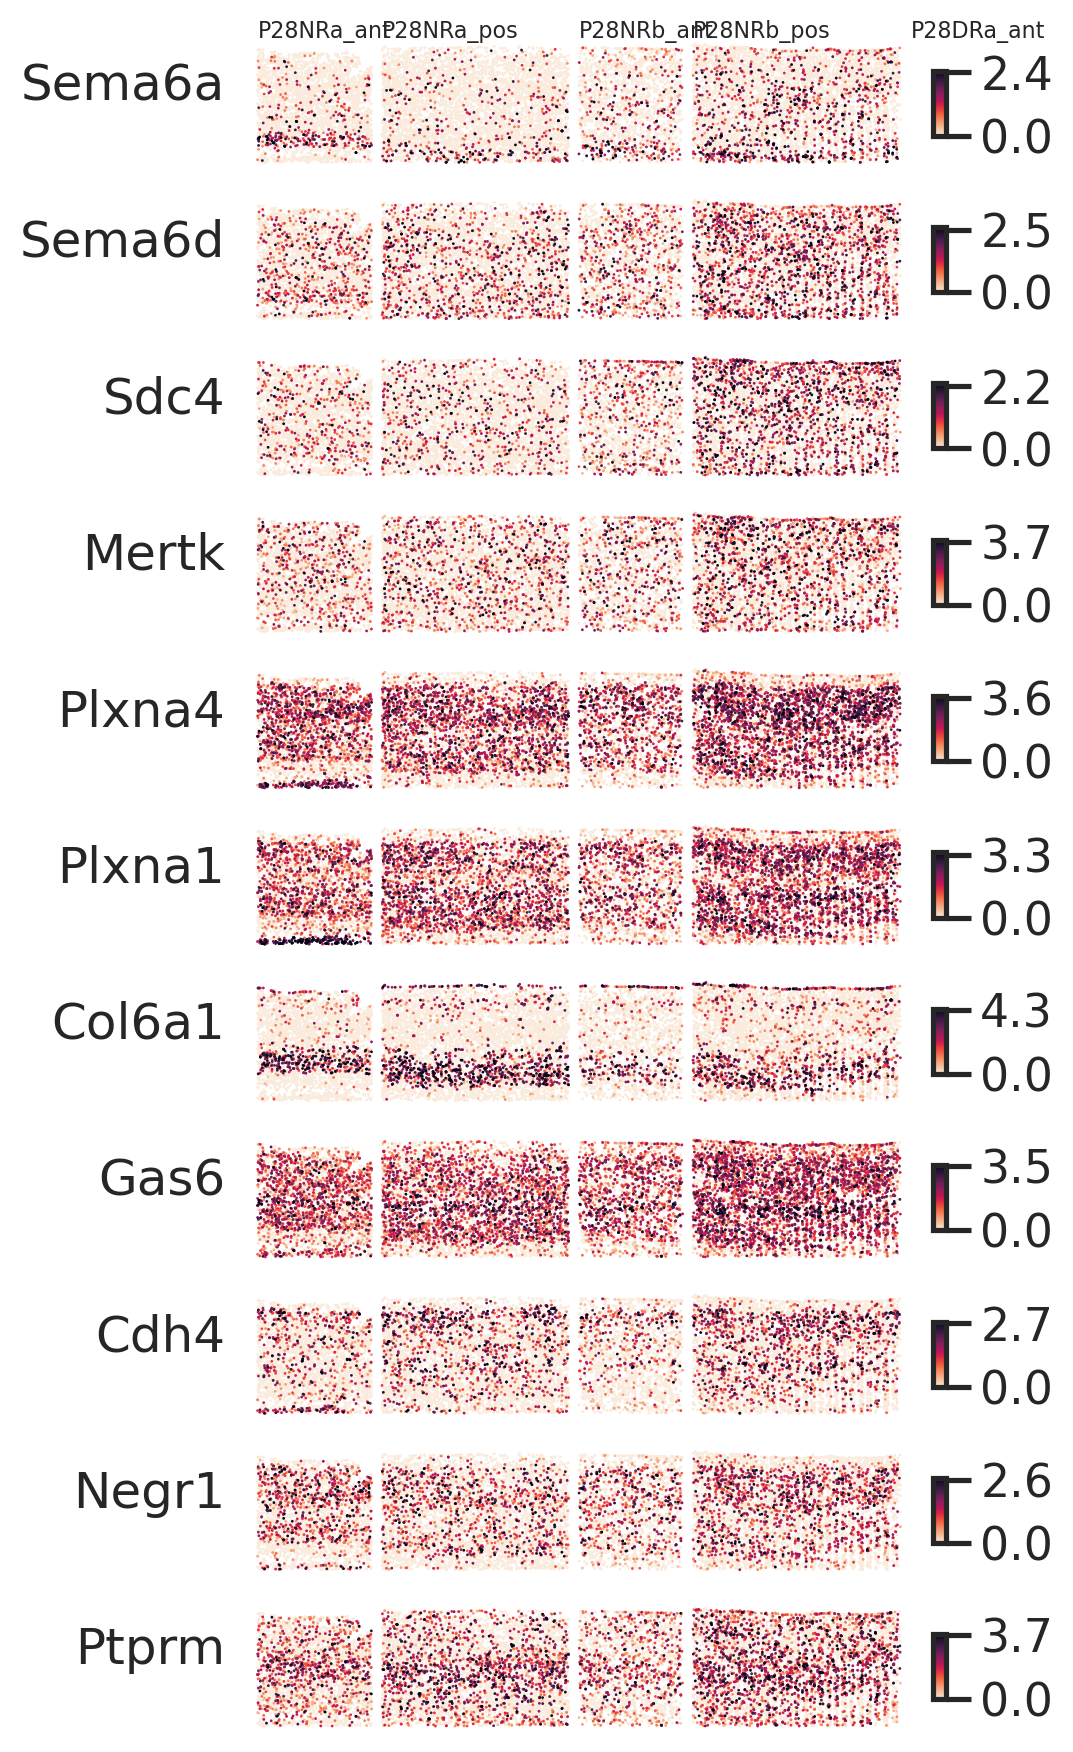

In [71]:


adata_data_raw = adata_merged_nr
adata_meta = adata_mer_nr

gns = [ 
       'Sema6a', 'Sema6d', 'Sdc4', 'Mertk', 
       'Plxna4', 'Plxna1', 'Col6a1', 'Gas6',
       'Cdh4', 'Negr1', 'Ptprm',
      ] 
n = len(gns)
x =  adata_meta.obs['width_show2']
y =  adata_meta.obs['depth_show2']

fig, axs = plt.subplots(n,1,figsize=(1*10,n*1))
for i, (ax, gn) in enumerate(zip(axs, gns)):
    # sample titles
    if i == 0:
        for lbl, coord in width_cum.items():
            ax.text(coord, 100, lbl, fontsize=8)# , pad=20)
    
    g = adata_data_raw[:,gn].layers['ljnorm'].reshape(-1,)
    vmax = np.percentile(g, 99)
    vmin = np.percentile(g,  0)
    sorting = np.argsort(g)
    
    p = utils_merfish.st_scatter_ax(fig, ax,  x[sorting],  y[sorting],  gexp=g[sorting], s=1, title='', vmin=vmin, vmax=vmax, cmap='rocket_r')
    # p = utils_merfish.st_scatter_ax(fig, ax,  x,  y,  gexp=g, s=1, title='', vmin=vmin, vmax=vmax, cmap='rocket_r')
    ax.set_title(gn, loc='left', va='center', ha='right', y=0.5, pad=None)
    fig.colorbar(p, pad=0, shrink=0.5, aspect=5, ticks=[np.round(vmin, decimals=1), np.round(vmax-0.1, decimals=1)])
    
fig_manager.savefig(fig)
plt.show()
    

saved the figure to: /u/home/f/f7xiesnm/project-zipursky/v1-bb/results_v1astro/260114/18_2026-01-14.pdf
/u/home/f/f7xiesnm/project-zipursky/v1-bb/results_v1astro/260114/18.pdf


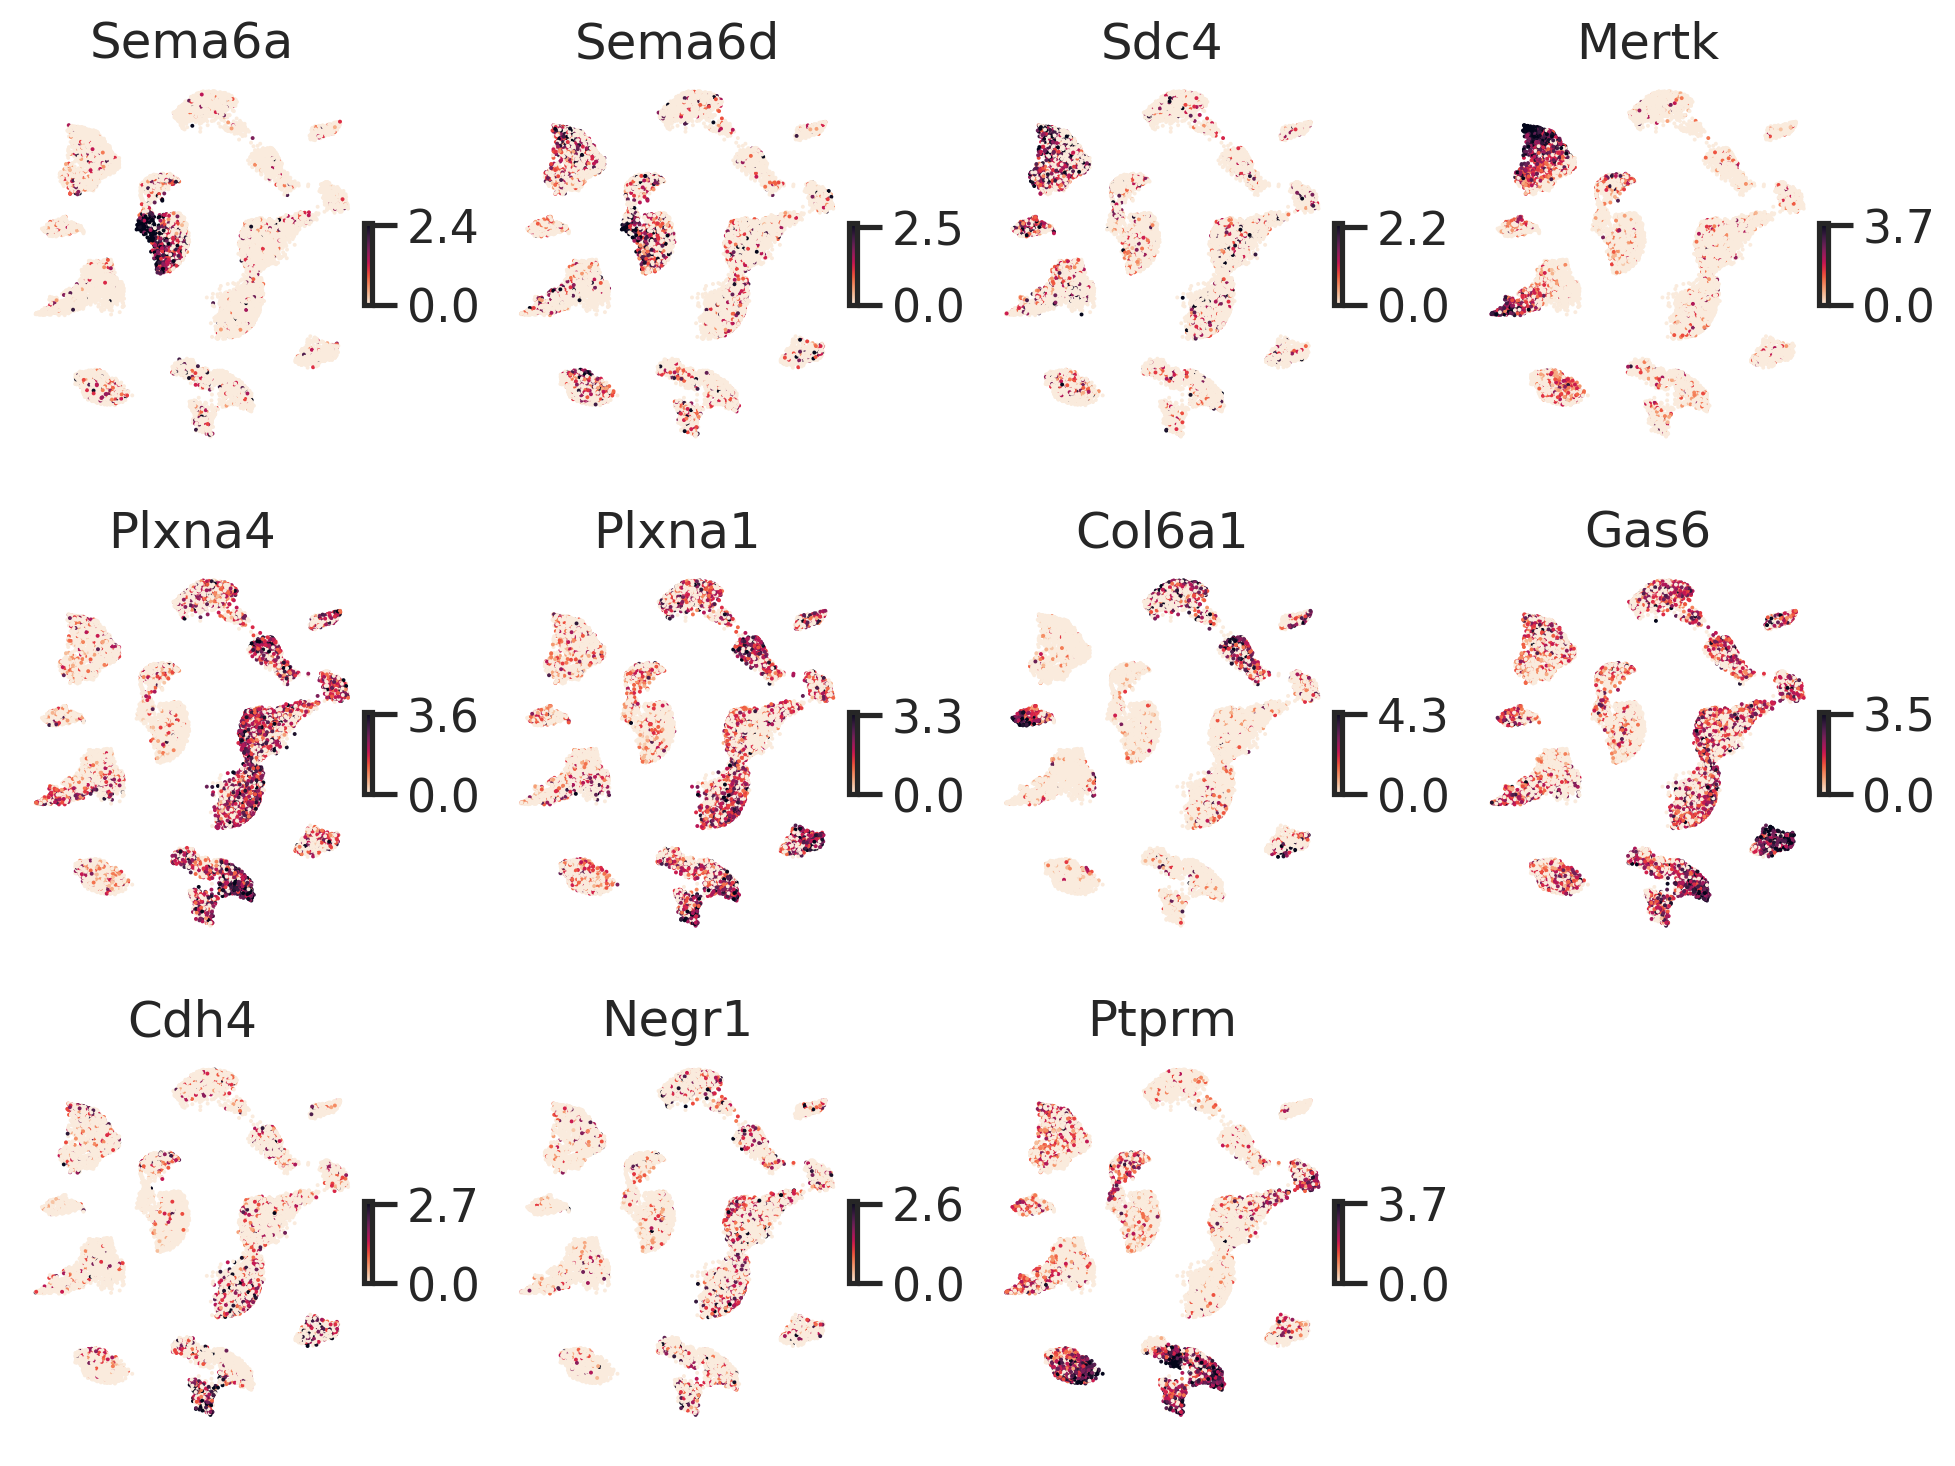

In [65]:
adata_data_raw = adata_merged_nr
adata_meta = adata_mer_nr

gns = [ 
       'Sema6a', 'Sema6d', 'Sdc4', 'Mertk', 
       'Plxna4', 'Plxna1', 'Col6a1', 'Gas6',
       'Cdh4', 'Negr1', 'Ptprm',
      ] 
n = len(gns)
x =  adata_meta.obs['umap1']
y =  adata_meta.obs['umap2']

nx = 4
ny = int((n+nx-1)/nx)

fig, axs = plt.subplots(ny,nx,figsize=(3*nx,ny*3))
for i, (ax, gn) in enumerate(zip(axs.flat, gns)):
    
    g = adata_data_raw[:,gn].layers['ljnorm'].reshape(-1,)
    vmax = np.percentile(g, 99)
    vmin = np.percentile(g,  0)
    sorting = np.argsort(g)
    
    # p = utils_merfish.st_scatter_ax(fig, ax,  x[sorting],  y[sorting],  gexp=g[sorting], s=2, title='', vmin=vmin, vmax=vmax, cmap='rocket_r')
    p = utils_merfish.st_scatter_ax(fig, ax,  x,  y,  gexp=g, s=2, title='', vmin=vmin, vmax=vmax, cmap='rocket_r')
    ax.set_title(gn)
    fig.colorbar(p, pad=0, shrink=0.2, aspect=10, ticks=[np.round(vmin, decimals=1), np.round(vmax-0.1, decimals=1)])

for ax in axs.flat[i:]:
    ax.axis('off')
    
fig_manager.savefig(fig)
plt.show()
    

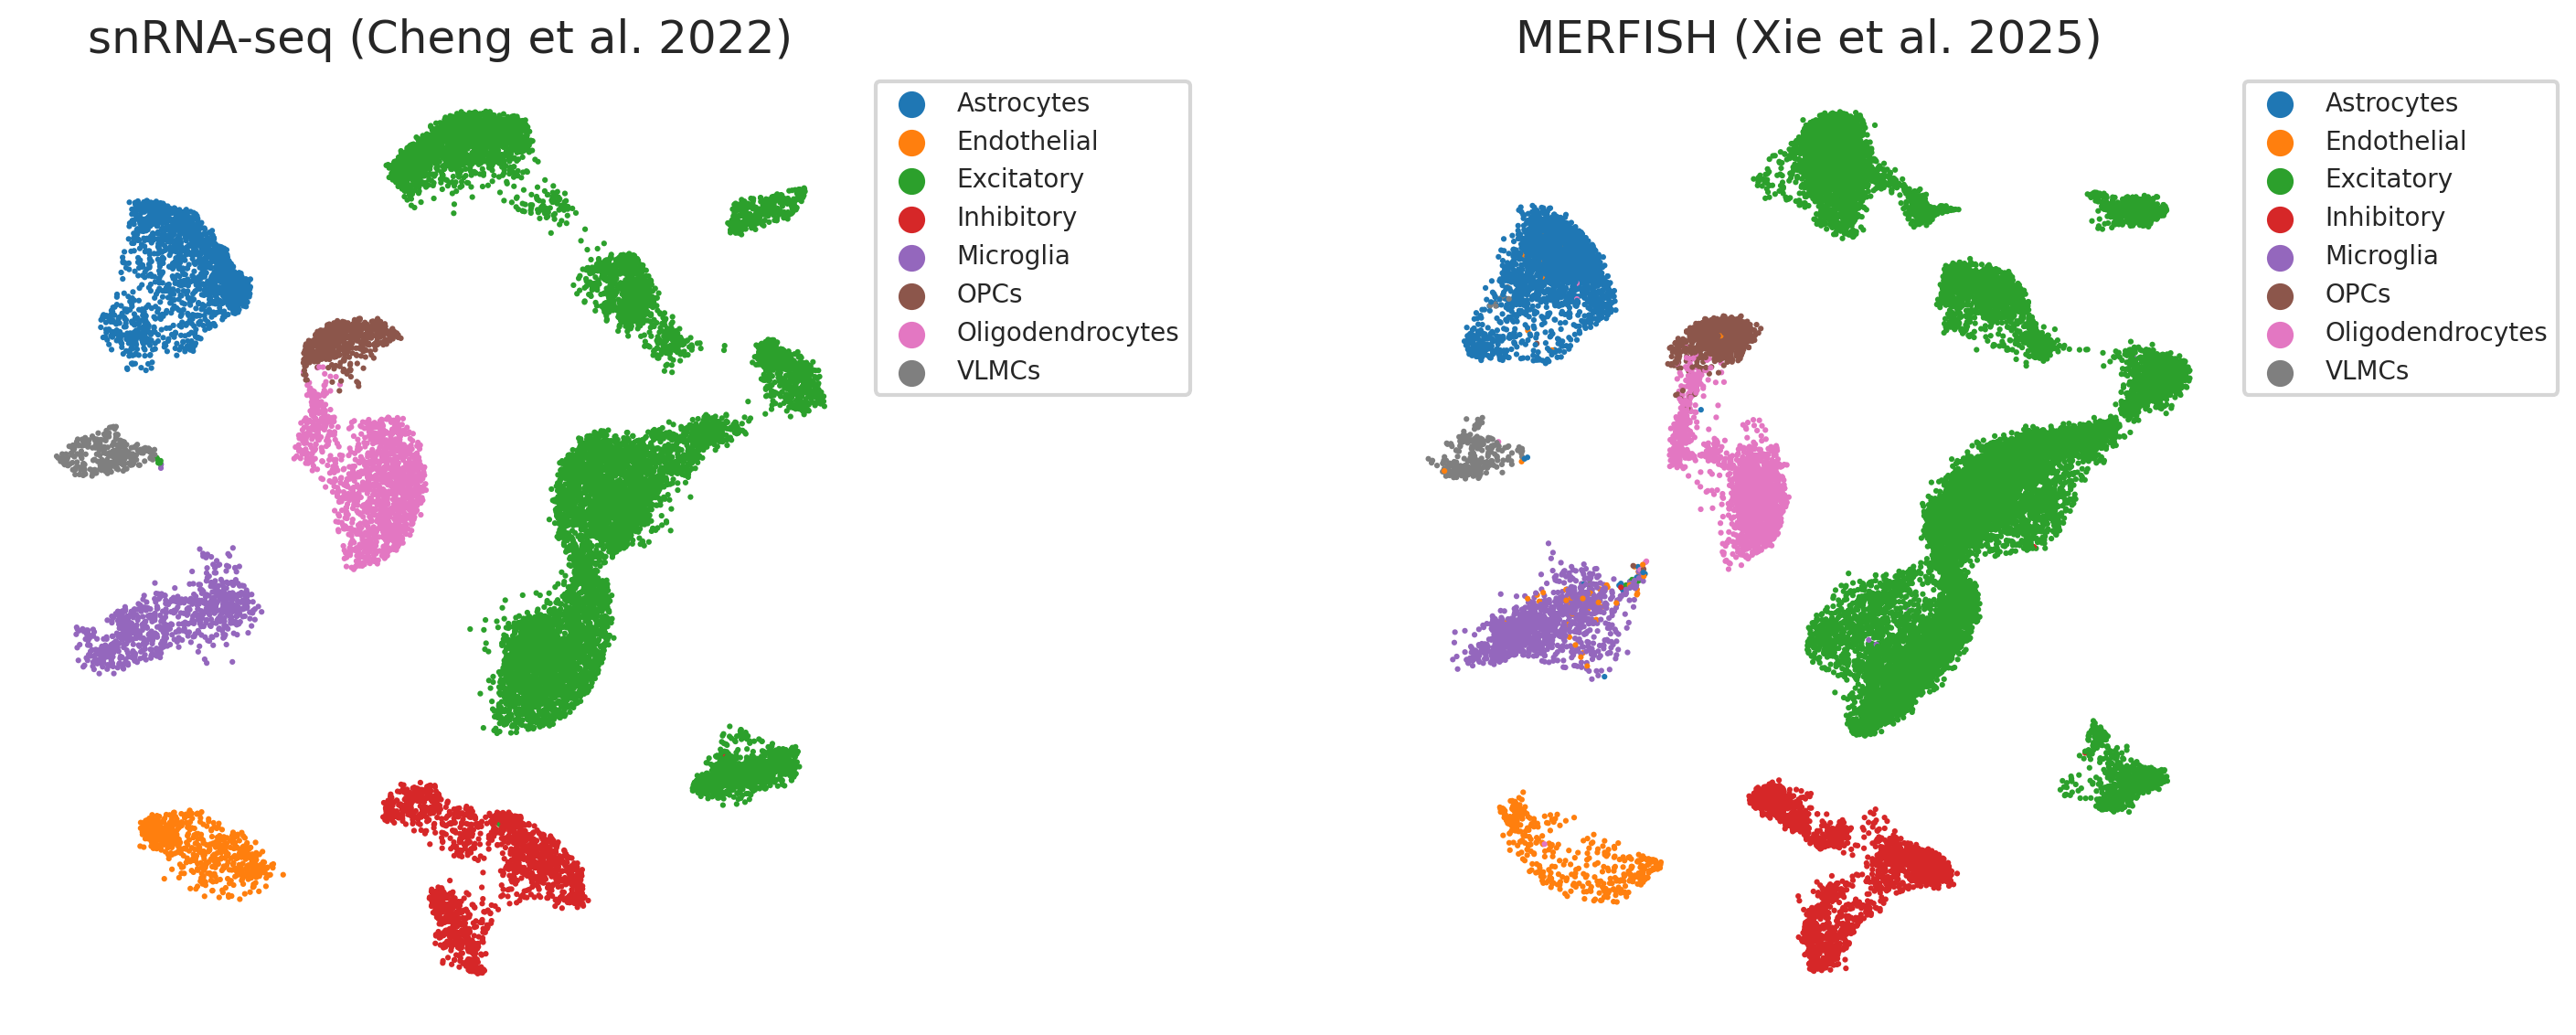

In [83]:
fig, axs = plt.subplots(1,2,figsize=(8*2,6), sharex=True, sharey=True)
x = 'umap1'
y = 'umap2'
# hue = 'uSubclass'
hue = 'uClass'
for ax, adata_mod in zip(axs, [adata_mer_nr, adata_rna]):
    sns.scatterplot(data=adata_mod.obs.sample(frac=1, replace=False), 
                    x=x, y=y, 
                    hue=hue, 
                    # palette=clsts_palette3, hue_order=list(clsts_palette3.keys()),
                    s=5, edgecolor='none', ax=ax, rasterized=True)
    ax.axis('off')
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1,1), fontsize=10)

axs[0].set_title('snRNA-seq (Cheng et al. 2022)')
axs[1].set_title('MERFISH (Xie et al. 2025)')
# powerplots.savefig_autodate(fig, os.path.join(outdir, 'fig1_umap_exc.pdf'))
fig.tight_layout()
plt.show()



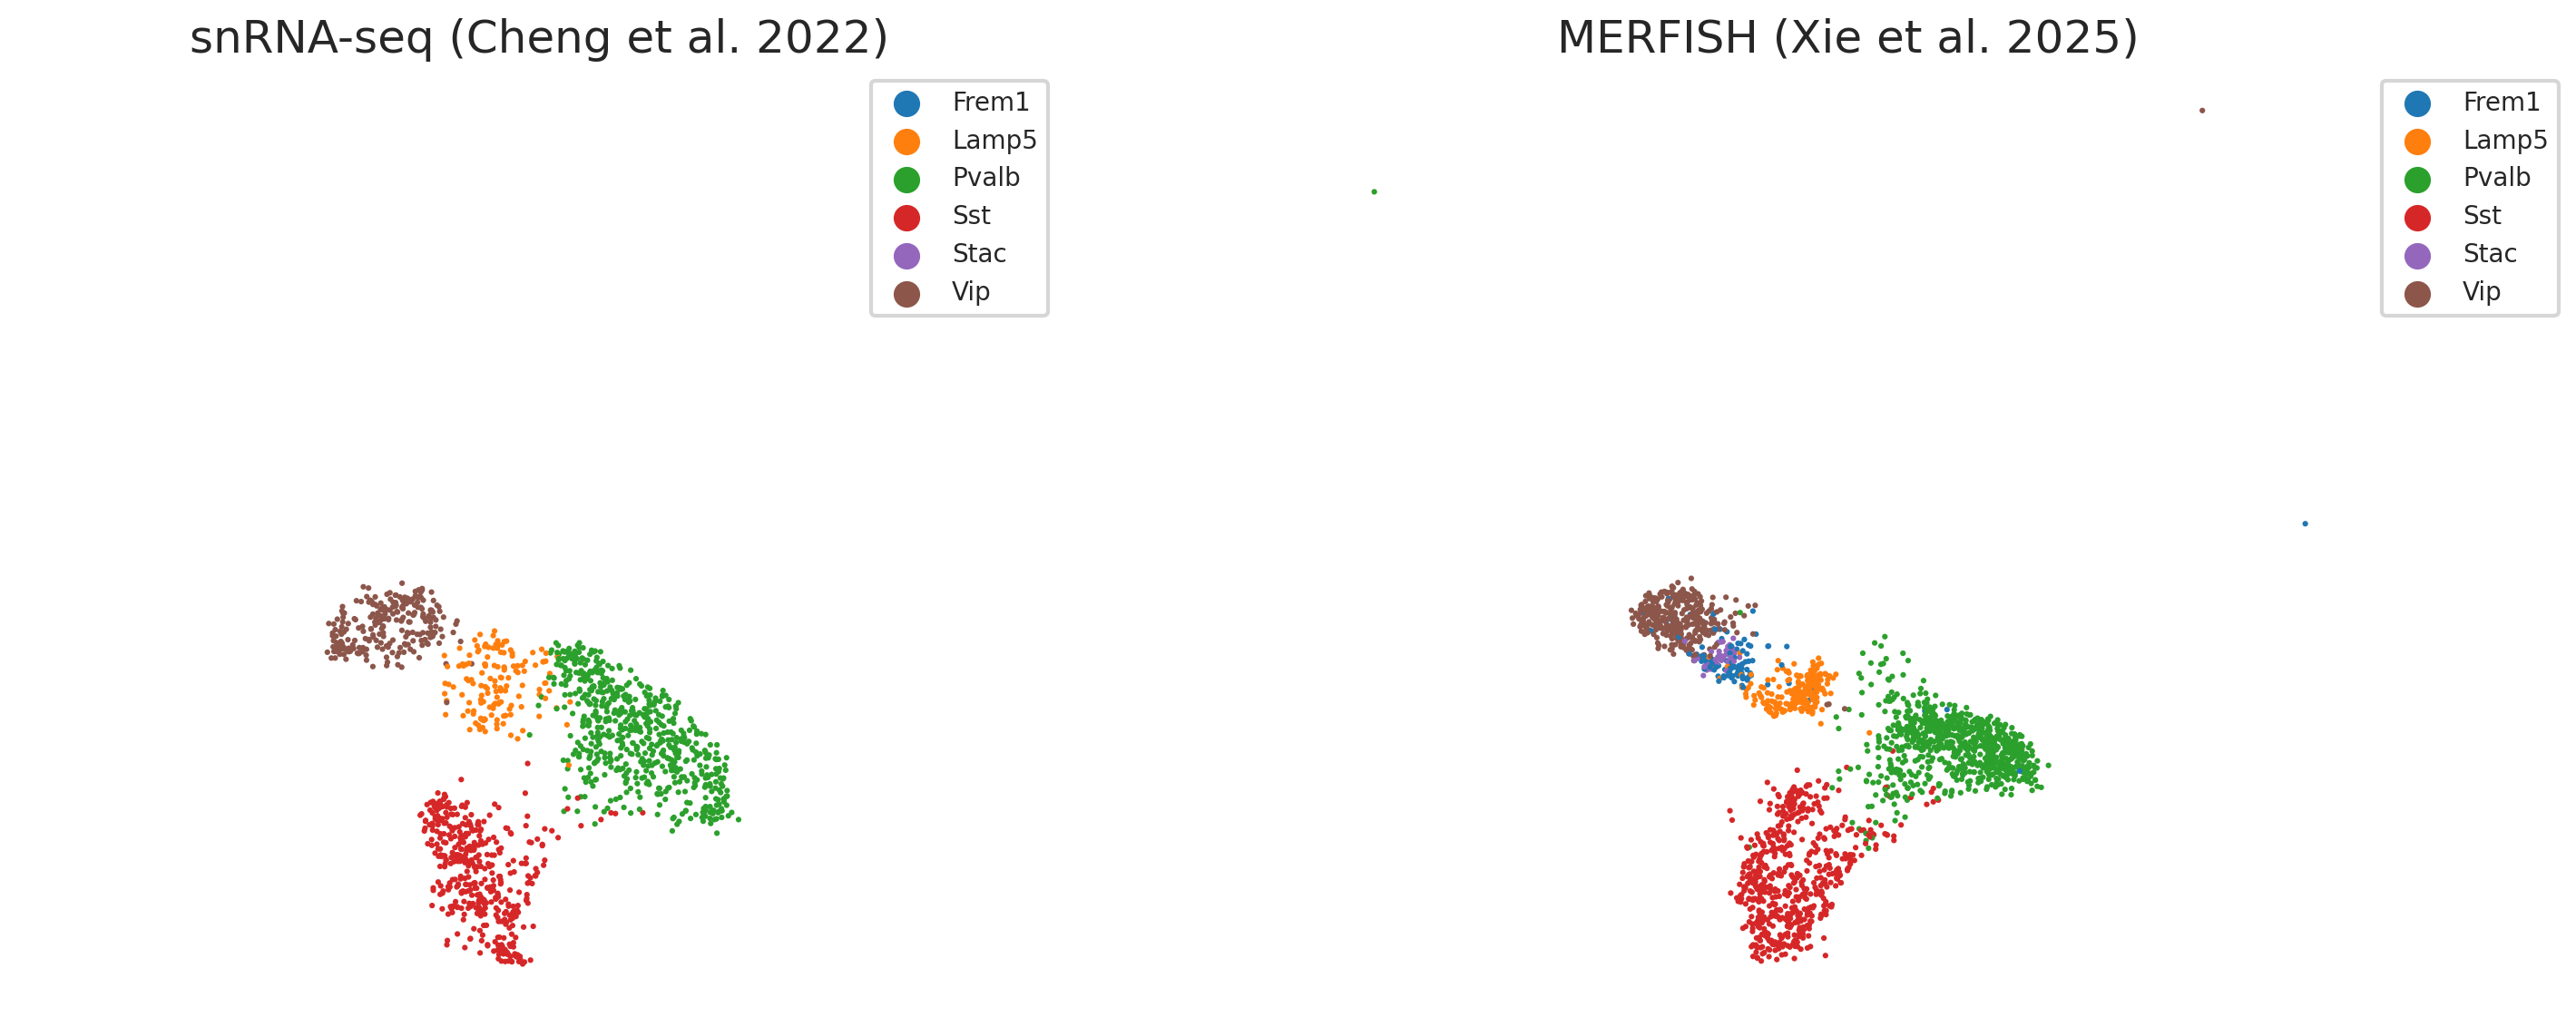

In [86]:

fig, axs = plt.subplots(1,2,figsize=(8*2,6), sharex=True, sharey=True)
x = 'umap1'
y = 'umap2'
hue = 'uSubclass'

include = ['Inhibitory']
include_by = 'uClass'

hue_order = np.sort(adata_rna.obs[adata_rna.obs[include_by].isin(include)][hue].unique())

for ax, adata_mod in zip(axs, [adata_mer_nr, adata_rna]):
    sns.scatterplot(data=adata_mod.obs[adata_mod.obs[include_by].isin(include)].sample(frac=1, replace=False), 
                    x=x, y=y, 
                    hue=hue, 
                    hue_order=hue_order,
                    # palette=clsts_palette3, hue_order=list(clsts_palette3.keys()),
                    s=5, edgecolor='none', ax=ax, rasterized=True)
    ax.axis('off')
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1,1), fontsize=10)

axs[0].set_title('snRNA-seq (Cheng et al. 2022)')
axs[1].set_title('MERFISH (Xie et al. 2025)')
# powerplots.savefig_autodate(fig, os.path.join(outdir, 'fig1_umap_exc.pdf'))
fig.tight_layout()
plt.show()


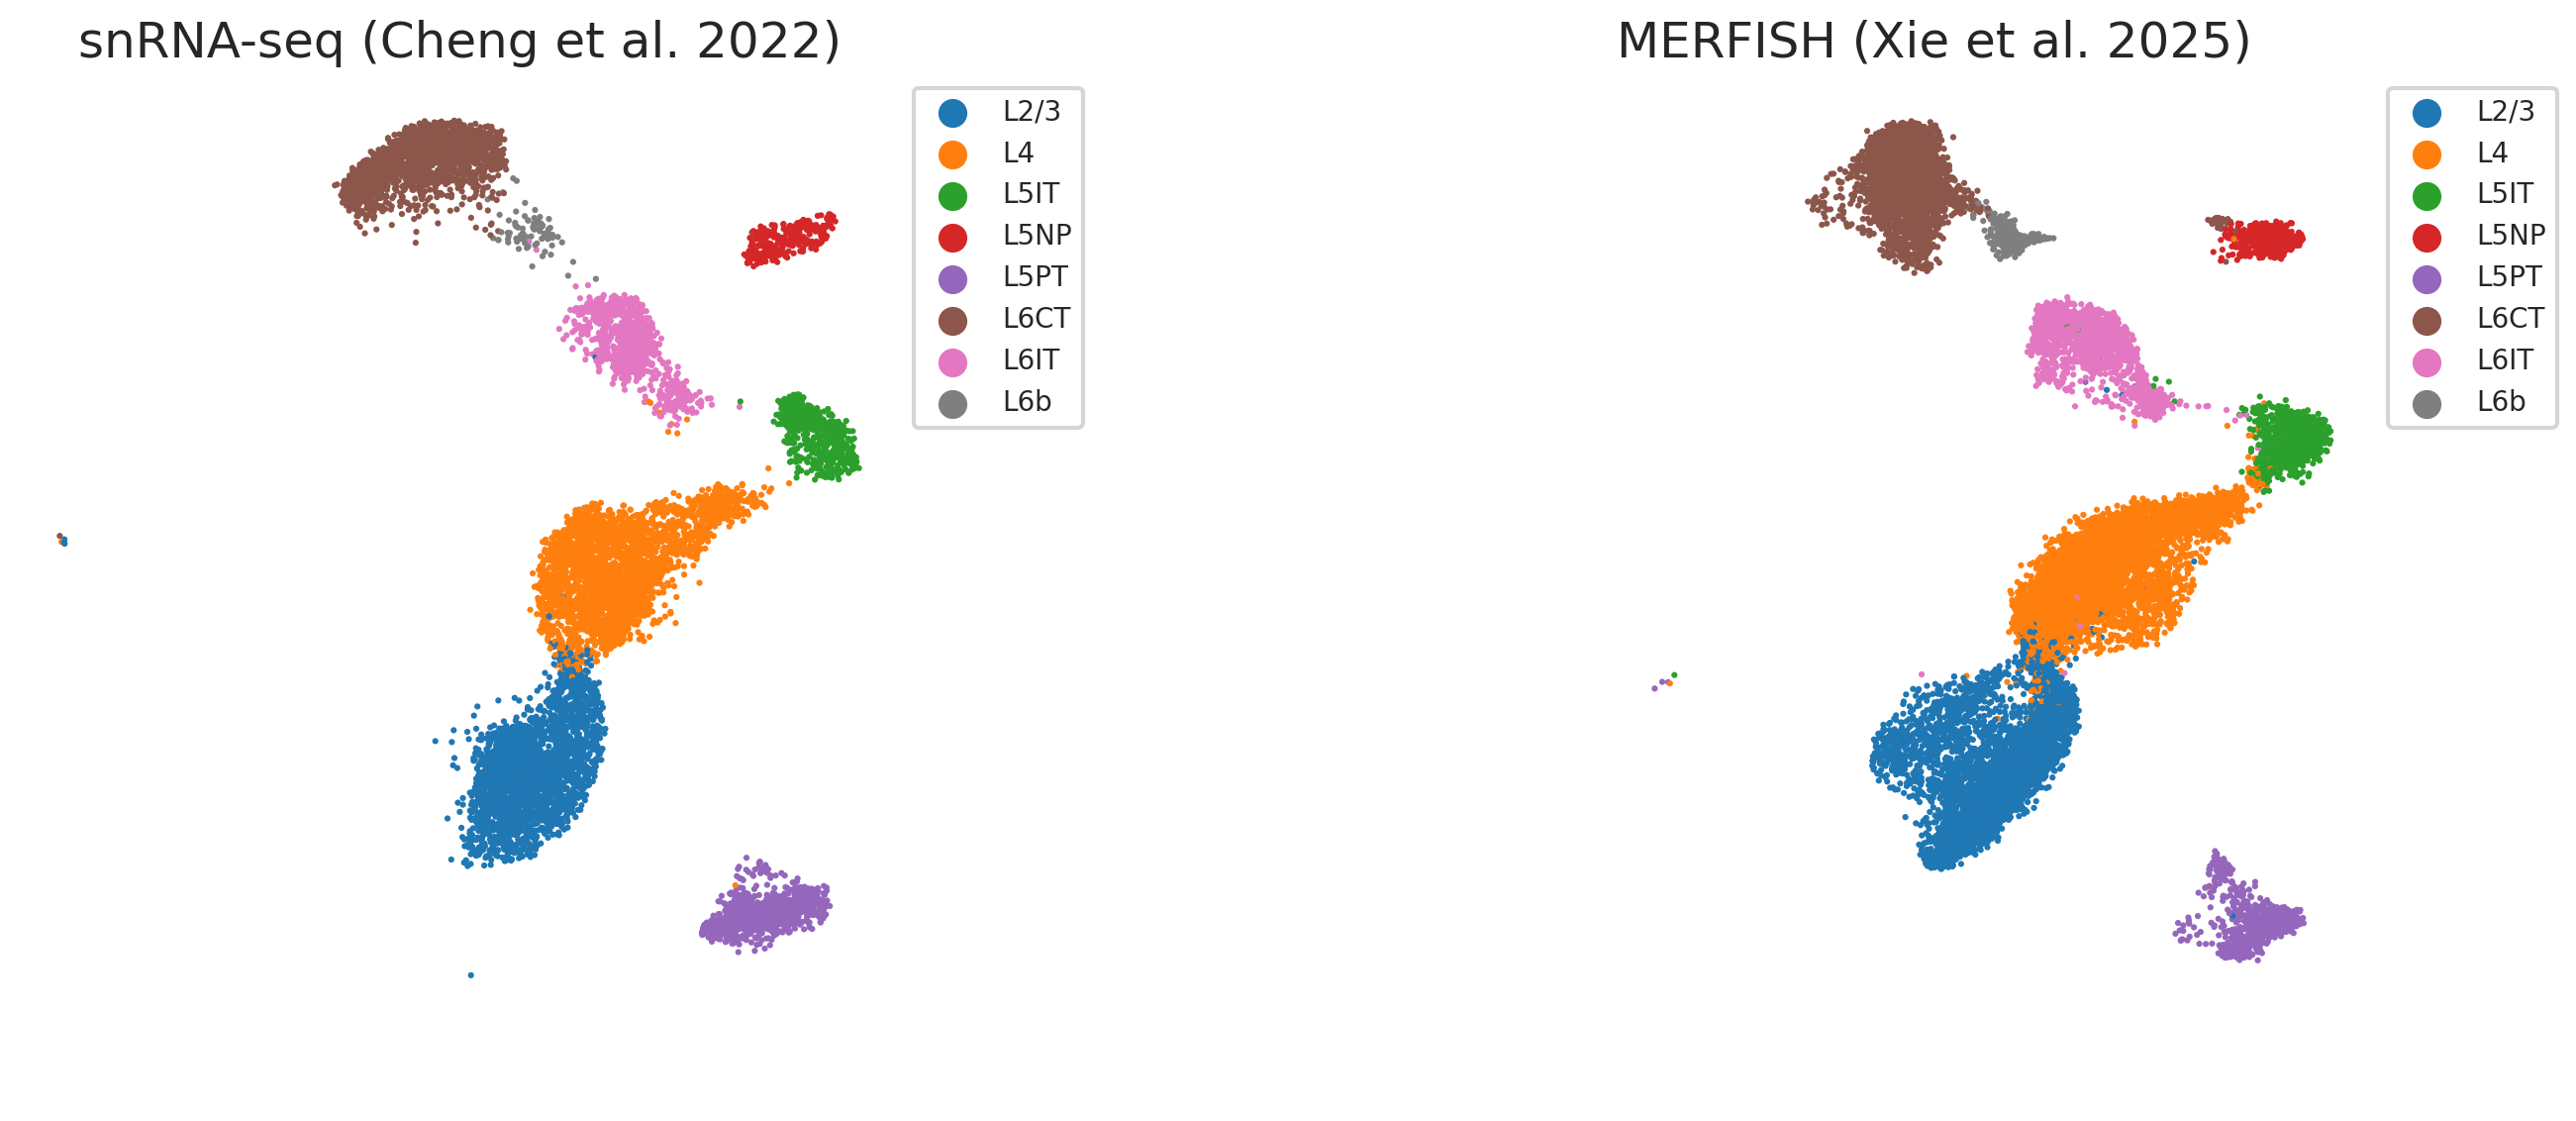

In [87]:
fig, axs = plt.subplots(1,2,figsize=(8*2,6), sharex=True, sharey=True)
x = 'umap1'
y = 'umap2'
hue = 'uSubclass'

include = ['Excitatory']
include_by = 'uClass'

hue_order = np.sort(adata_rna.obs[adata_rna.obs[include_by].isin(include)][hue].unique())

for ax, adata_mod in zip(axs, [adata_mer_nr, adata_rna]):
    sns.scatterplot(data=adata_mod.obs[adata_mod.obs[include_by].isin(include)].sample(frac=1, replace=False), 
                    x=x, y=y, 
                    hue=hue, 
                    hue_order=hue_order,
                    # palette=clsts_palette3, hue_order=list(clsts_palette3.keys()),
                    s=5, edgecolor='none', ax=ax, rasterized=True)
    ax.axis('off')
    ax.set_aspect('equal')
    ax.legend(bbox_to_anchor=(1,1), fontsize=10)

axs[0].set_title('snRNA-seq (Cheng et al. 2022)')
axs[1].set_title('MERFISH (Xie et al. 2025)')
# powerplots.savefig_autodate(fig, os.path.join(outdir, 'fig1_umap_exc.pdf'))
fig.tight_layout()
plt.show()